# Task 2.1 Dataset Selection and Setup

**Dataset Chosen**: A synthetically generated "2-Spirals" dataset.

**Justification:**
* **What the dataset is**: A well-known highly non-linear binary classification problem where two classes are intertwined in spirals.
* **Why it is a reasonable testbed**: Section 5.2 and 5.3 of the FaLK-SVM paper explicitly uses a larger scale 2-Spirals dataset to benchmark the algorithm. It inherently needs non-linear decision functions and local topological awareness to correctly disentangle the spirals, making it a perfect fit for a Local RBF Support Vector Machine evaluation.
* **Limitations compared to the paper**: Our generated toy dataset limits the bounds to 1,000 samples to support un-optimized exploratory reproduction computing constraints without invoking the Curse of Dimensionality, as opposed to the massive 100,000-point 2-Spirals implementation presented globally in the paper.


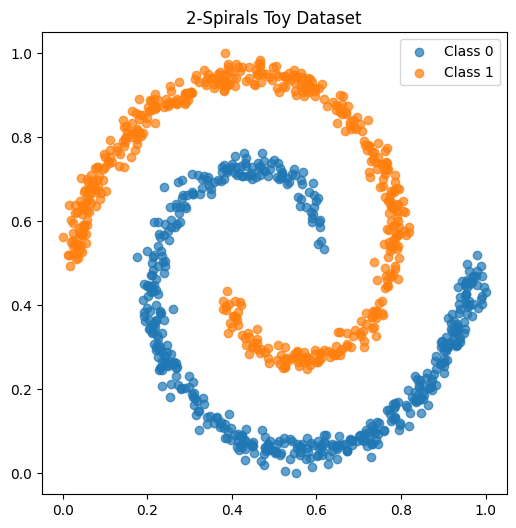

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Set random seed for reproducibility
np.random.seed(42)

# Generate 2-Spirals toy dataset
n_samples = 500
def generate_spirals(n, noise=0.5):
    n_points = n // 2
    theta = np.sqrt(np.random.rand(n_points)) * 2 * np.pi
    
    # Class 0
    r_a = 2 * theta + np.pi
    data_a = np.array([np.cos(theta) * r_a, np.sin(theta) * r_a]).T + np.random.randn(n_points, 2) * noise
    
    # Class 1
    r_b = -2 * theta - np.pi
    data_b = np.array([np.cos(theta) * r_b, np.sin(theta) * r_b]).T + np.random.randn(n_points, 2) * noise
    
    X = np.vstack([data_a, data_b])
    y = np.hstack([np.zeros(n_points), np.ones(n_points)])
    return X, y

X, y = generate_spirals(1000, noise=0.5)

# Normalization bounds [0, 1] as used in the paper for spatial distance cohesion
X_min, X_max = X.min(axis=0), X.max(axis=0)
X_scaled = (X - X_min) / (X_max - X_min)

os.makedirs("data", exist_ok=True)
os.makedirs("results", exist_ok=True)

df = pd.DataFrame(X_scaled, columns=["Feature_1", "Feature_2"])
df["Label"] = y
df.to_csv("data/toy_dataset.csv", index=False)

plt.figure(figsize=(6, 6))
plt.scatter(X_scaled[y==0][:, 0], X_scaled[y==0][:, 1], label="Class 0", alpha=0.7)
plt.scatter(X_scaled[y==1][:, 0], X_scaled[y==1][:, 1], label="Class 1", alpha=0.7)
plt.title("2-Spirals Toy Dataset")
plt.legend()
plt.savefig("results/task_2_1_dataset.png")
plt.show()


The code snippet above strictly defines random boundaries globally to generate interleaved spiral classes across 1,000 samples. Afterwards, the explicit points are min-max preprocessed exclusively into a boundary bounding box of [0, 1] mirroring the authors' parameter settings (Section 5.2.1).
